In [27]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as hf
import jax.numpy as jnp
import jax
from functools import partial

In [2]:
def compute_rdf(position_data: np.ndarray, reference_data):
    """
    Compute an rdf on colloids positions w.r.t the rod center.
    
    Parameters
    ----------
    data : np.ndarray (time_steps, colloids, 3)
    """
    # Convert to polar coordinates
    def inner_fn(
        position: jnp.ndarray, reference
    ):
        origin = jnp.array([500., 500., 0.])
        distance_vector = position - origin
        distance = jnp.linalg.norm(distance_vector)
        normed_distance = distance_vector / distance
        
        angle = jnp.arctan2(
            normed_distance[0] * reference[1] - normed_distance[1] * reference[0],
            normed_distance[0] * reference[0] + normed_distance[1] * reference[1]
        )
        return jnp.array([distance, angle])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, None))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    polar_coordinates = outer_map_fn(
        position_data, reference_data
    )
    
    # Convert to cartesian coordinates
    def inner_fn(
        distance: jnp.ndarray, angle: jnp.ndarray
    ):
        x = distance * jnp.cos(angle)
        y = distance * jnp.sin(angle)
        
        return jnp.array([x, y])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, 0))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    cartesian_coords = outer_map_fn(
        polar_coordinates[:, :, 0], polar_coordinates[:, :, 1]
    )
        
    return cartesian_coords  

In [40]:
def compute_rod_velocity(data: np.ndarray):
    """
    Compute rod velocity.
    
    Parameters
    ----------
    data : np.ndarray (time_steps, 1, 3)
    """
#     x = jnp.linspace(0, data.shape[0] - 1, data.shape[0] - 1) * 0.1
    reference = data[0]
    angles = []
    
    for item in data[1:]:
        angles.append(
            jnp.arctan2(
                item[0] * reference[1] - item[1] * reference[0],
                item[0] * reference[0] + item[1] * reference[1]
            )
        )
    
    return jnp.gradient(jnp.array(angles))

In [43]:
def compute_velocity_observable(temperature, indices):
    vel_op = jax.jit(compute_rod_velocity)
    
    ref_velocity = []
    ref_velocity_err = []
    velocity = []
    velocity_err = []
    
    # Compute reference velocity
    for j in range(1, 11, 1):
        with hf.File(f"OLD/{temperature}/{j}/no_colloids/trajectory.hdf5", "r") as db:
            rod_references = db["colloids"]["Directors"][:, 10, :]        
        
        rod_vel = np.abs(compute_rod_velocity(rod_references))
        ref_velocity.append(np.mean(rod_vel))
        ref_velocity_err.append(np.std(rod_vel) / np.sqrt(rod_vel.shape[0]))
    
    # Compute active velocity
    for i in range(1, 11, 1):
        with hf.File(f"{temperature}/{i}/deployment/trajectory.hdf5", "r") as db:
            rod_references = db["colloids"]["Directors"][:, 50, :]
        
        rod_vel = np.abs(compute_rod_velocity(rod_references[1000:]))
        velocity.append(np.mean(rod_vel))
        velocity_err.append(np.std(rod_vel) / np.sqrt(rod_vel.shape[0]))    
    
    
    final_velocity = np.mean(velocity) - np.mean(ref_velocity)
    driven_error = np.sqrt(np.sum(np.array(velocity_err) ** 2))
    free_error = np.sqrt(np.sum(np.array(ref_velocity) ** 2))
    final_err = np.sqrt(driven_error ** 2 + free_error ** 2)
    
    return velocity, velocity_err, ref_velocity, ref_velocity_err

In [44]:
results = {
    "0K": {"indices": [1, 2, 3, 4, 5, 6, 7, 9, 10]},
    "150K": {"indices": [1, 2, 3, 4, 5, 6, 8, 9, 10]},
    "273K": {"indices": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
    "300K": {"indices": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
    "350K": {"indices": [1, 2, 4, 5, 6, 7, 8, 10]},
}

for temp in ["0K", "150K", "273K", "300K", "350K"]:
    velocity, velocity_error, reference_velocity, reference_velocity_error = compute_velocity_observable(
        temp, results[temp]["indices"]
    )
    results[temp]["velocity"] = velocity
    results[temp]["velocity_error"] = velocity_error
    results[temp]["reference_velocity"] = reference_velocity
    results[temp]["reference_velocity_errors"] = reference_velocity_error

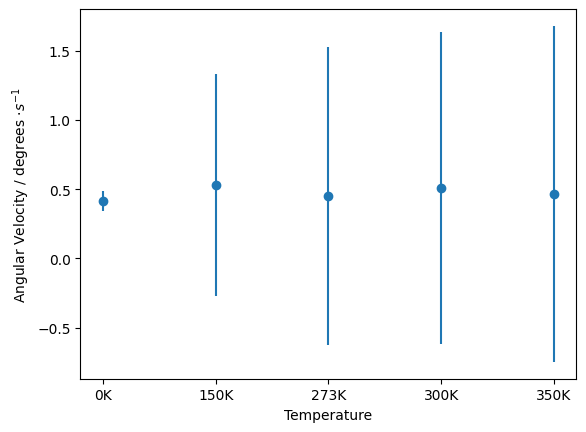

In [6]:
y = [57.2958 * item["velocity"] for item in results.values()]
yerr = [57.2958 * item["error"] for item in results.values()]
x = list(results)

plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="none")

plt.xlabel("Temperature")
plt.ylabel(r"Angular Velocity / degrees $\cdot s^{-1}$")
plt.show()

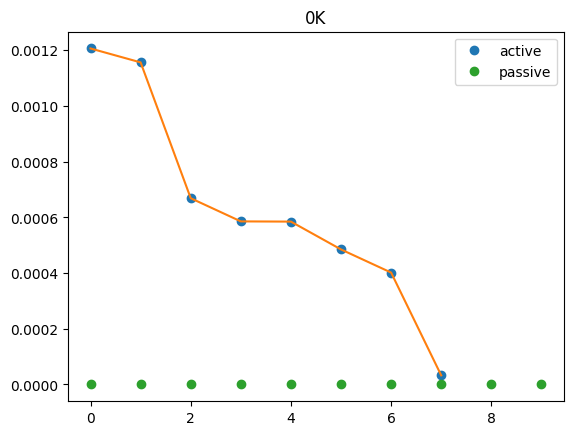

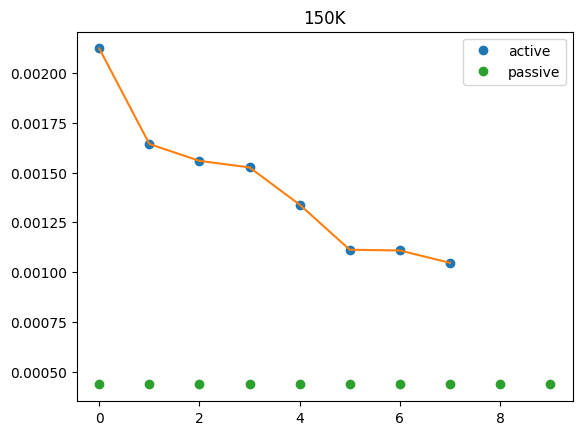

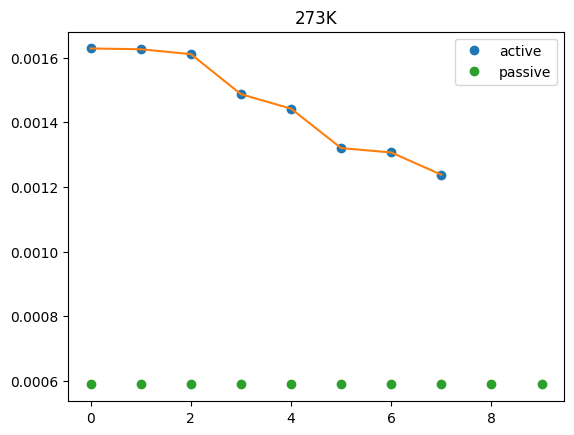

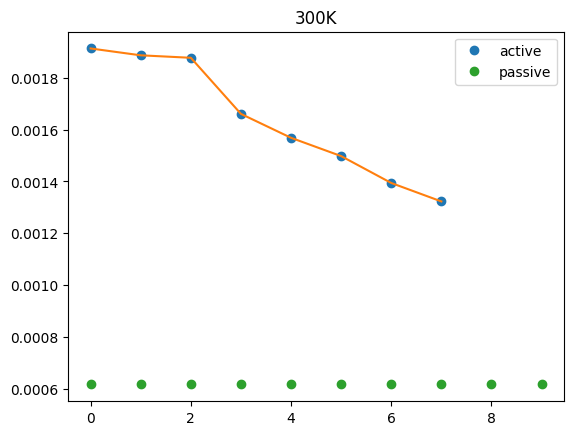

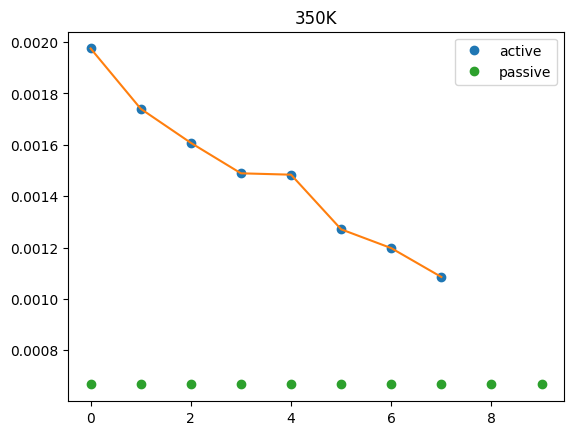

In [91]:
for item in results:
    plt.plot(np.sort(results[item]["velocity"])[::-1][:8], 'o', label="active")
    plt.plot(np.sort(np.take(results[item]["velocity"], results[item]["indices"] - 1))[::-1])
    plt.plot(results[item]["reference_velocity"], 'o', label="passive")
#     plt.axhline(np.mean(results[item]["velocity"]))
#     plt.axhline(np.mean(results[item]["velocity"]) - np.mean(results[item]["reference_velocity"]), color='r')

    plt.legend()
    plt.title(item)
    plt.show()

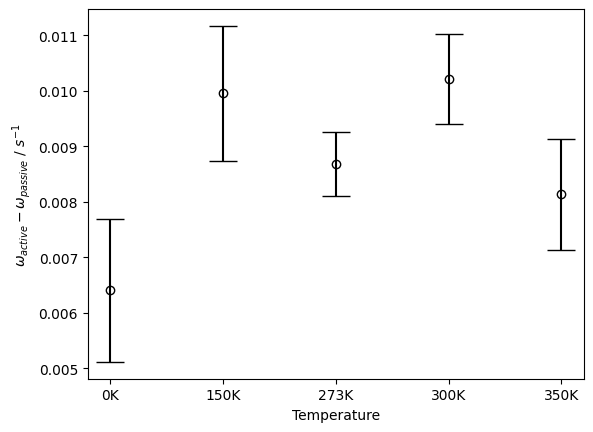

In [100]:
means = []
errs = []

for item in results:
    
    # Collect active velocity data
    active_velocities = np.take(
        results[item]["velocity"], results[item]["indices"] - 1
    )
    active_velocity_err = np.take(
        results[item]["velocity_error"], results[item]["indices"] - 1
    )
    
    # Collect passive velocity data
    passive_velocities = np.array(results[item]["reference_velocity"])
    passive_velocities_err = np.array(results[item]["reference_velocity_errors"])
    
    means.append(np.mean(active_velocities) - np.mean(passive_velocities))
    
    ensemble_err = np.sqrt(
        (np.std(active_velocities) / np.sqrt(8)) ** 2 + (np.std(passive_velocities) / np.sqrt(10)) ** 2
    )
    
    active_measurement_err = np.sqrt(np.sum(active_velocity_err ** 2)) / 8
    passive_measurement_err = np.sqrt(np.sum(passive_velocities_err ** 2)) / 10
    
    measurement_err = np.sqrt(active_measurement_err ** 2 + passive_measurement_err ** 2)
    
    errs.append(
        np.sqrt(ensemble_err ** 2 + measurement_err ** 2)
    )

plt.errorbar(
    list(results), 
    np.array(means) / 0.1,
    yerr=np.array(errs) / 0.1,
    fmt="ko",
    markerfacecolor="none",
    capsize=10
)
plt.xlabel("Temperature")
plt.ylabel(r"$\omega_{active} - \omega_{passive}$ / $s^{-1}$")
plt.show()

In [83]:
for item in results:
    results[item]["indices"] = np.sort(np.argsort(results[item]["velocity"])[-8:] + 1)

In [102]:
np.save("vel_results.npy", results)

In [104]:
np.argsort(results["150K"]["velocity"])

array([6, 2, 5, 0, 7, 8, 3, 9, 1, 4])